<a href="https://colab.research.google.com/github/ZVSCR/UNIFESP_Numerical_Analysis/blob/main/Atividade_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Principal da simulação


In [ ]:
def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula a difusao de velocidade usando Euler Explicito e detecta falhas."""
    H = 0.01          # Distancia entre placas (m)
    nu = 1e-4         # Viscosidade cinematica (m^2/s)

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficiente adimensional r
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Condicoes iniciais: fluido parado, placa em y=0 se move a U=1 m/s
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos (overflow/invalid) em excecoes
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Discretizacao de Euler Explicito
                novo[1:-1] = (
                    u[1:-1] + r * (u[2:] - dois * u[1:-1] + u[:-2])
                )
            except FloatingPointError as erro:
                falha = passo
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
        "dy": dy
    }

# Verifica estabilidade

In [ ]:
H, nu, pontos = 0.01, 1e-4, 21
dy = H / (pontos - 1)
dt_max = (dy**2) / (2 * nu)

print(f"Espacamento espacial (dy): {dy:.6f} m")
print(f"Passo de tempo maximo teorico (dt_max): {dt_max:.6f} s")

for dt in (0.001, 0.002):
    r = nu * dt / (dy**2)
    status = "ESTÁVEL" if r <= 0.5 else "INSTÁVEL"
    print(f"dt = {dt}s -> r = {r:.2f} ({status})")

Espacamento espacial (dy): 0.000500 m
Passo de tempo maximo teorico (dt_max): 0.001250 s
dt = 0.001s -> r = 0.40 (ESTÁVEL)
dt = 0.002s -> r = 0.80 (INSTÁVEL)


# Detecção de Overflow e tipo num


In [ ]:
resultados = {}

print(f"{'Tipo':<10} | {'dt (s)':<8} | {'r':<6} | {'Overflow?':<10} | {'Iteracao da Falha'}")
print("-" * 55)

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        res = simular(dt, tipo=tipo, passos=2000, pontos=21)
        resultados[nome] = res

        overflow_str = "Sim" if res["falha"] is not None else "Nao"
        falha_str = str(res["falha"]) if res["falha"] is not None else "N/A"
        print(f"{tipo.__name__:<10} | {dt:<8} | {res['r']:<6.2f} | {overflow_str:<10} | {falha_str}")

Tipo       | dt (s)   | r      | Overflow?  | Iteracao da Falha
-------------------------------------------------------
float32    | 0.001    | 0.40   | Nao        | N/A
float32    | 0.002    | 0.80   | Sim        | 121
float64    | 0.001    | 0.40   | Nao        | N/A
float64    | 0.002    | 0.80   | Sim        | 917


# Gráfico de crescimento de | u |

/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


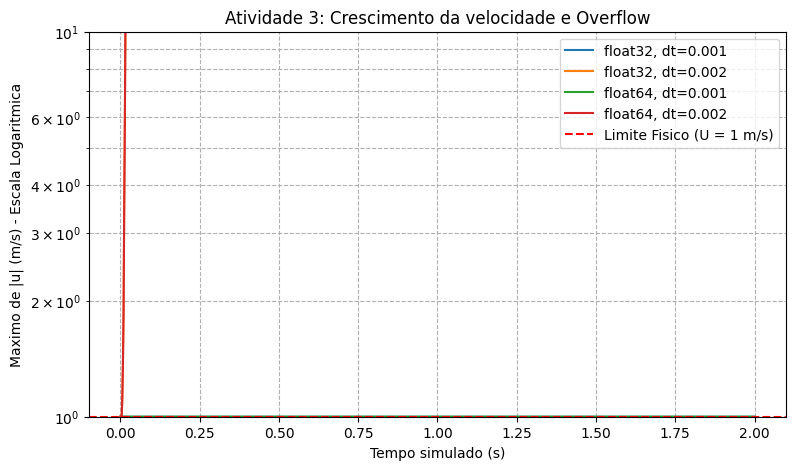

In [ ]:
plt.figure(figsize=(9, 5))
for nome, res in resultados.items():
    plt.semilogy(res["tempos"], res["maximos"], label=nome)

plt.axhline(y=1.0, color='r', linestyle='--', label="Limite Fisico (U = 1 m/s)")
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - Escala Logaritmica")
plt.title("Atividade 3: Crescimento da velocidade e Overflow")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

# Refinamento de malha

In [ ]:
pontos_novo = 41
dy_novo = H / (pontos_novo - 1)
dt_max_novo = (dy_novo**2) / (2 * nu)

print(f"Novo dy (41 pontos): {dy_novo:.6f} m")
print(f"Novo dt_max: {dt_max_novo:.6f} s")

# Teste 1 com dt = 0.001s na malha refinada (deve falhar pois dt > dt_max)
res_m41_instavel = simular(dt=0.001, tipo=np.float64, passos=2000, pontos=41)
print(f"dt = 0.001s, r = {res_m41_instavel['r']:.2f} -> Falha no passo: {res_m41_instavel['falha']}")

# Teste 2 com dt estavel abaixo do novo limite
dt_estavel_novo = 0.0002
res_m41_estavel = simular(dt=dt_estavel_novo, tipo=np.float64, passos=10000, pontos=41)
print(f"dt = {dt_estavel_novo}s, r = {res_m41_estavel['r']:.2f} -> Falha: {res_m41_estavel['falha']} (Estavel!)")

Novo dy (41 pontos): 0.000250 m
Novo dt_max: 0.000312 s
dt = 0.001s, r = 1.60 -> Falha no passo: 426
dt = 0.0002s, r = 0.32 -> Falha: None (Estavel!)


# Verificação do Perfil de Velocidade e Solução Estacionária

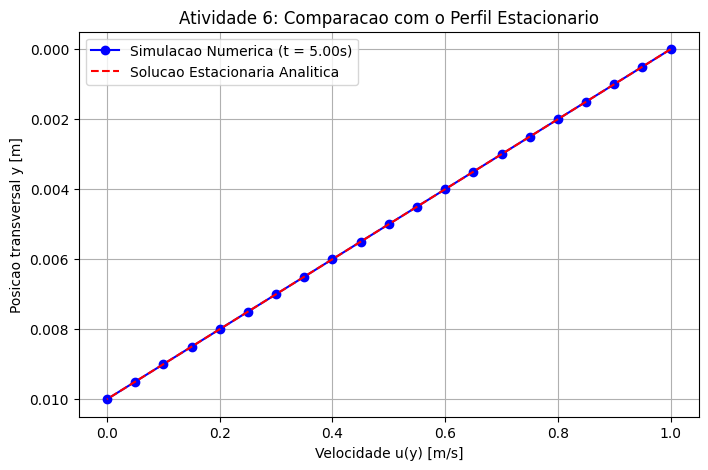

Erro maximo em relacao ao regime estacionario (E_inf): 3.441691e-15


In [ ]:
# Execucao longa e estavel para atingir regime permanente
res_longo = simular(dt=0.001, tipo=np.float64, passos=5000, pontos=21)

y_nodes = res_longo["y"]
u_num = res_longo["u"]
u_est = 1.0 * (1 - y_nodes / H)  # Solucao analitica estacionaria: U*(1 - y/H)

# Erro maximo em relacao ao perfil estacionario
erro_inf = np.max(np.abs(u_num - u_est))

plt.figure(figsize=(8, 5))
plt.plot(u_num, y_nodes, 'bo-', label=f"Simulacao Numerica (t = {res_longo['tempos'][-1]:.2f}s)")
plt.plot(u_est, y_nodes, 'r--', label="Solucao Estacionaria Analitica")
plt.xlabel("Velocidade u(y) [m/s]")
plt.ylabel("Posicao transversal y [m]")
plt.title("Atividade 6: Comparacao com o Perfil Estacionario")
plt.grid(True)
plt.legend()
plt.gca().invert_yaxis()  # Placa movel em y=0 no topo
plt.show()

print(f"Erro maximo em relacao ao regime estacionario (E_inf): {erro_inf:.6e}")